In [3]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from timeit import default_timer

In [4]:
class U_net(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size, dropout_rate):
        super(U_net, self).__init__()
        self.input_channels = input_channels
        self.conv1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv2 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv2_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)
        self.conv3 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv3_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)
        
        self.deconv2 = self.deconv(input_channels, output_channels)
        self.deconv1 = self.deconv(input_channels*2, output_channels)
        self.deconv0 = self.deconv(input_channels*2, output_channels)
    
        self.output_layer = self.output(input_channels*2, output_channels, 
                                         kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)


    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        concat2 = torch.cat((out_conv2, out_deconv2), 1)
        out_deconv1 = self.deconv1(concat2)
        concat1 = torch.cat((out_conv1, out_deconv1), 1)
        out_deconv0 = self.deconv0(concat1)
        concat0 = torch.cat((x, out_deconv0), 1)
        out = self.output_layer(concat0)

        return out

    def conv(self, in_planes, output_channels, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv3d(in_planes, output_channels, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias = False),
            nn.BatchNorm3d(output_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate)
        )

    def deconv(self, input_channels, output_channels):
        return nn.Sequential(
            nn.ConvTranspose3d(input_channels, output_channels, kernel_size=4,
                               stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def output(self, input_channels, output_channels, kernel_size, stride, dropout_rate):
        return nn.Conv3d(input_channels, output_channels, kernel_size=kernel_size,
                         stride=stride, padding=(kernel_size - 1) // 2)

In [5]:
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, modes3):
        super(SpectralConv3d, self).__init__()

        """
        3D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 #Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes2
        self.modes3 = modes3

        self.scale = (1 / (in_channels * out_channels*1600))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights3 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights5 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul3d(self, input, weights):
        # (batch, in_channel, x,y,t ), (in_channel, out_channel, x,y,t) -> (batch, out_channel, x,y,t)
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfftn(x, dim=[-3,-2,-1])

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2, :self.modes3]   = self.compl_mul3d(x_ft[:, :, :self.modes1,  :self.modes2,  :self.modes3], self.weights1)
        out_ft[:, :, :self.modes1, -self.modes2:, :self.modes3]  = self.compl_mul3d(x_ft[:, :, :self.modes1,  -self.modes2:, :self.modes3], self.weights3)#
        out_ft[:, :, :self.modes1,  :self.modes2, -self.modes3:] = self.compl_mul3d(x_ft[:, :, :self.modes1,  :self.modes2, -self.modes3:], self.weights5)#

        #Return to physical space
        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x

class FNO3d(nn.Module):
    def __init__(self, modes1, modes2, modes3, width):
        super(FNO3d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the first 10 timesteps + 3 locations (u(1, x, y), ..., u(10, x, y),  x, y, t). It's a constant function in time, except for the last index.
        input shape: (batchsize, x=64, y=64, t=40, c=13)
        output: the solution of the next 40 timesteps
        output shape: (batchsize, x=64, y=64, t=40, c=1)
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3
        self.width = width
        self.padding = 6 # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(7, self.width)
        # input channel is 12: the solution of the first 10 timesteps + 3 locations (u(1, x, y), ..., u(10, x, y),  x, y, t)

        self.conv0 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv1 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv2 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv3 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv4 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        #self.conv5 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        #self.conv6 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        #self.conv7 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)


        self.unet0 = U_net(self.width, self.width, 3, 0)
        self.unet1 = U_net(self.width, self.width, 3, 0)
        self.unet2 = U_net(self.width, self.width, 3, 0)
        self.unet3 = U_net(self.width, self.width, 3, 0)
        self.unet4 = U_net(self.width, self.width, 3, 0)
        #self.unet5 = U_net(self.width, self.width, 3, 0)
        #self.unet6 = U_net(self.width, self.width, 3, 0)
        #self.unet7 = U_net(self.width, self.width, 3, 0)

        self.w0 = nn.Conv3d(self.width, self.width, 1)
        self.w1 = nn.Conv3d(self.width, self.width, 1)
        self.w2 = nn.Conv3d(self.width, self.width, 1)
        self.w3 = nn.Conv3d(self.width, self.width, 1)
        self.w4 = nn.Conv3d(self.width, self.width, 1)
        #self.w5 = nn.Conv3d(self.width, self.width, 1)
        #self.w6 = nn.Conv3d(self.width, self.width, 1)
        #self.w7 = nn.Conv3d(self.width, self.width, 1)

        
        self.bn0 = torch.nn.BatchNorm3d(self.width)
        self.bn1 = torch.nn.BatchNorm3d(self.width)
        self.bn2 = torch.nn.BatchNorm3d(self.width)
        #self.bn3 = torch.nn.BatchNorm3d(self.width)
        #self.bn4 = torch.nn.BatchNorm3d(self.width)

        self.fc1 = nn.Linear(self.width, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, C1, W1, dx, dy, dt):
        grid = self.get_grid(dx, dy, dt, C1.shape, C1.device)
        #print("this is the shape of C1", C1.shape)
        #print("this is the shape of W1", W1.shape)
        #print("this is the shape of grid", grid.shape)
        
        x = torch.cat((C1, W1, grid), dim=-1)
        x = self.fc0(x)
        x = x.permute(0, 4, 1, 2, 3)
        #x = F.pad(x, [0,self.padding]) # pad the domain if input is non-periodic

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x3 = self.unet0(x)
        x = (x1 + x2 + x3)
        x = F.gelu(x)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x3 = self.unet1(x)
        x = (x1 + x2 + x3)
        x = F.gelu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x3 = self.unet2(x)
        x = (x1 + x2 + x3)
        x = F.gelu(x)
        #x = x[..., :-self.padding]
        x = x.permute(0, 2, 3, 4, 1) # pad the domain if input is non-periodic
        x = self.fc1(x)
        #x = F.gelu(x)
        x = self.fc2(x)
        return x

    def get_grid(self, dx, dy, dz, shape, device):
        batchsize, size_x, size_y, size_z = shape[0], shape[1], shape[2], shape[3]
        gridx = torch.tensor(np.linspace(0, dx*size_x, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1, 1).repeat([batchsize, 1, size_y, size_z, 1])
        gridy = torch.tensor(np.linspace(0, dy*size_y, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1, 1).repeat([batchsize, size_x, 1, size_z, 1])
        gridz = torch.tensor(np.linspace(0, dz*size_z, size_z), dtype=torch.float)
        gridz = gridz.reshape(1, 1, 1, size_z, 1).repeat([batchsize, size_x, size_y, 1, 1])
        return torch.cat((gridx, gridy, gridz), dim=-1).to(device)

In [6]:
N_models = 1000
DATA_PATH = './CFNO_Data_set_low_freq_test/'
vx_x_train1 = torch.load(DATA_PATH+'/vx_x_data_set_training_2024_0916_test1.pt')
vx_x_train2 = torch.load(DATA_PATH+'/vx_x_data_set_training_2024_0916_test2.pt')
vx_x_train = torch.cat((vx_x_train1,vx_x_train2), dim=0)

del vx_x_train1, vx_x_train2
print("this is the shape of the vx_x_train original size",vx_x_train.shape)

vp_train1  = torch.load(DATA_PATH+'/vp_data_set_training_2024_0916_test1.pt')
vp_train2  = torch.load(DATA_PATH+'/vp_data_set_training_2024_0916_test2.pt')
vp_train = torch.cat((vp_train1, vp_train2), dim=0)
del vp_train1, vp_train2

vs_train1  = torch.load(DATA_PATH+'/vs_data_set_training_2024_0916_test1.pt')
vs_train2  = torch.load(DATA_PATH+'/vs_data_set_training_2024_0916_test2.pt')
vs_train =  torch.cat((vs_train1, vs_train2), dim=0)
del vs_train1, vs_train2

rho_train1  = torch.load(DATA_PATH+'/rho_data_set_training_2024_0916_test1.pt')
rho_train2  = torch.load(DATA_PATH+'/rho_data_set_training_2024_0916_test1.pt')
rho_train =  torch.cat((rho_train1, rho_train2), dim=0)
del rho_train1, rho_train2


this is the shape of the vx_x_train original size torch.Size([2000, 300, 64, 64])


In [7]:
vp_train = torch.as_tensor(vp_train,dtype=torch.float32)
vs_train = torch.as_tensor(vs_train,dtype=torch.float32)
rho_train = torch.as_tensor(rho_train,dtype=torch.float32)

num_model_samples, num_channels, nz, nx = vp_train.shape
vp_train_reshape = torch.unsqueeze((vp_train.permute(0, 2, 3,1))/1000, dim=-1)
vs_train_reshape = torch.unsqueeze((vs_train.permute(0, 2, 3,1))/1000, dim=-1)
rho_train_reshape =torch.unsqueeze((rho_train.permute(0, 2, 3,1))/1000, dim=-1)

Models_train = torch.cat((vp_train_reshape, vs_train_reshape, rho_train_reshape), dim=-1)
print(Models_train.shape)

del vp_train, vs_train, rho_train

torch.Size([2000, 64, 64, 1, 3])


In [8]:
vx_x_train = torch.as_tensor(vx_x_train,dtype=torch.float32)
num_model_samples, num_time_step, nz, nx = vx_x_train.shape
vx_x_train_reshape = torch.unsqueeze(torch.nn.functional.normalize(vx_x_train.permute(0, 2, 3, 1)), dim=-1)

del vx_x_train

In [9]:
# Preparing the training and testing wavefields
ntrain = int(Models_train.shape[0]*0.9)
ntest  = int(Models_train.shape[0]*0.1)
sub = 1
t_max=201
input_time = 1
time_prediction_number = t_max - input_time

Models_train_sub  = Models_train[:ntrain,::sub,::sub,:]
Models_test_sub   = Models_train[-ntest:-1,::sub,::sub,:]
vx_x_train_reshape_sub  = vx_x_train_reshape[:ntrain,::sub,::sub,:t_max]
vx_x_test_reshape_sub   = vx_x_train_reshape[-ntest:-1,::sub,::sub,:t_max]
print(Models_train_sub.shape)
print(vx_x_train_reshape_sub.shape)
print(Models_test_sub.shape)
print(vx_x_test_reshape_sub.shape)

torch.Size([1800, 64, 64, 1, 3])
torch.Size([1800, 64, 64, 201, 1])
torch.Size([199, 64, 64, 1, 3])
torch.Size([199, 64, 64, 201, 1])


In [35]:
# start the training
mode1 = 12
mode2 = 12
mode3 = 12
width = 16
device = torch.device('cuda')

model = FNO3d(mode1, mode2, mode3, width).cuda()
model.load_state_dict(torch.load("./_model_add_velocity_0917_test4.pth"))

<All keys matched successfully>

In [48]:
training_loss_tensor= torch.load('./_training_loss_tensor_0917_test4.pt')
testing_loss_tensor = torch.load('./_testing_loss_tensor_0917_test4.pt')
#testing_loss_tenso

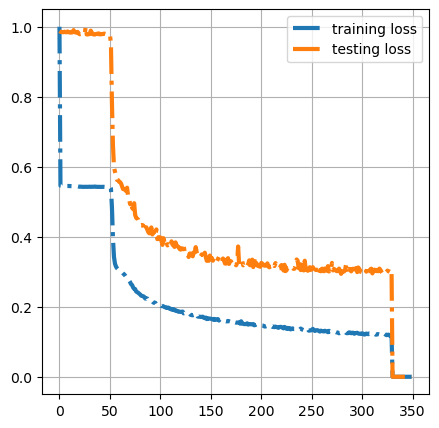

In [49]:
ep = 350
plt.figure(figsize=(5, 5))
plt.plot(training_loss_tensor[:ep]/training_loss_tensor[:ep].max(), '-.',linewidth=3, label='training loss')
plt.plot(testing_loss_tensor[:ep]/testing_loss_tensor[:ep].max(), '-.',linewidth=3, label='testing loss')
plt.legend(fontsize=10)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.grid()
#plt.yscale("log")

C:\Users\aangz\AppData\Local\Temp\ipykernel_26060\1123642684.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Model_index = int(np.random.randint(Models_train_sub.shape[0], size=1))


this is the shape of im_validation torch.Size([1, 64, 64, 200, 1])


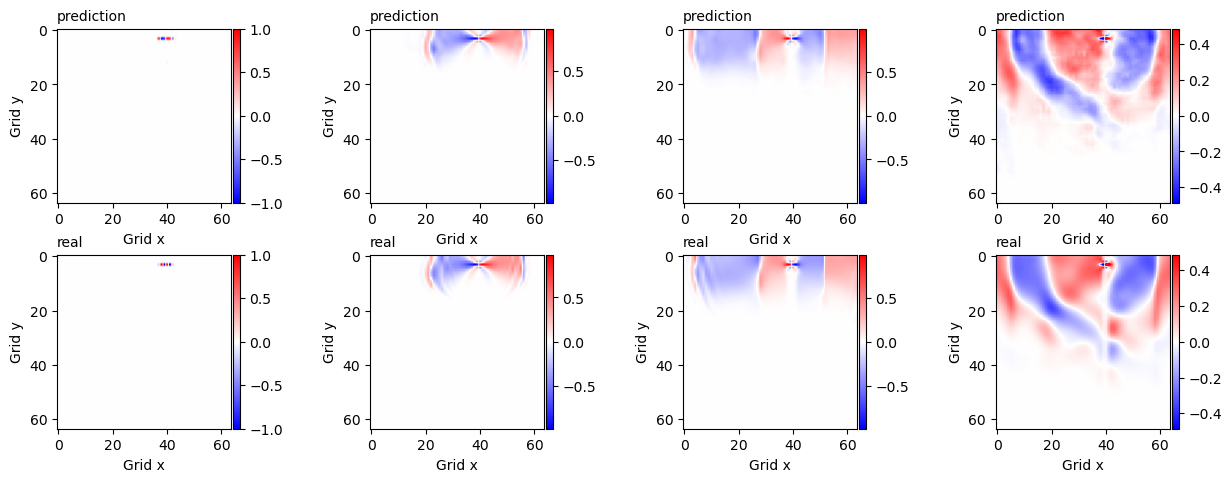

In [50]:
from Plotting_class import add_colorbar
Model_index = int(np.random.randint(Models_train_sub.shape[0], size=1))
with torch.no_grad():
    im_validation = model(torch.unsqueeze(Models_train_sub[Model_index,:,:,:].repeat(1,1,time_prediction_number,1), dim=0).to(device),  
                          torch.unsqueeze((vx_x_train_reshape_sub[Model_index,:,:,:input_time,:].permute(0, 1, 3, 2)).repeat(1, 1, time_prediction_number,1).to(device), dim=0), dx=40, dy=40, dt=0.002)
print("this is the shape of im_validation",im_validation.shape)

plot_time_step_1 = 0
plot_time_step_2 = 50
plot_time_step_3 = 100
plot_time_step_4 = -1


color = 'bwr'
fontsize_plt = 10
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(im_validation[:,:,:,plot_time_step_1].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().min(), 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 0])
im =ax.imshow(vx_x_train_reshape_sub[Model_index,:,:,plot_time_step_1].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().min(), 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


###############################################################################################

ax = fig.add_subplot(gs[0, 1])
im =ax.imshow(im_validation[:,:,:,plot_time_step_2].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().min(), 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 1])
im =ax.imshow(vx_x_train_reshape_sub[Model_index,:,:,plot_time_step_2].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().min(), 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


###############################################################################################

ax = fig.add_subplot(gs[0, 2])
im =ax.imshow(im_validation[:,:,:,plot_time_step_3].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().min(), 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().max())
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 2])
im =ax.imshow(vx_x_train_reshape_sub[Model_index,:,:,plot_time_step_3].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().min(), 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


###############################################################################################

ax = fig.add_subplot(gs[0, 3])
im =ax.imshow(im_validation[:,:,:,plot_time_step_4].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().min()/2, 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().max()/2)
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


ax = fig.add_subplot(gs[1, 3])
im =ax.imshow(vx_x_train_reshape_sub[Model_index,:,:,plot_time_step_4].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_train_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().min()/2, 
              vmax = vx_x_train_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().max()/2)
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

plt.subplots_adjust(left=0.125,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.3)

C:\Users\aangz\AppData\Local\Temp\ipykernel_26060\2155682220.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Model_index = int(np.random.randint(Models_test_sub.shape[0], size=1))


this is the shape of im_validation torch.Size([1, 64, 64, 200, 1])


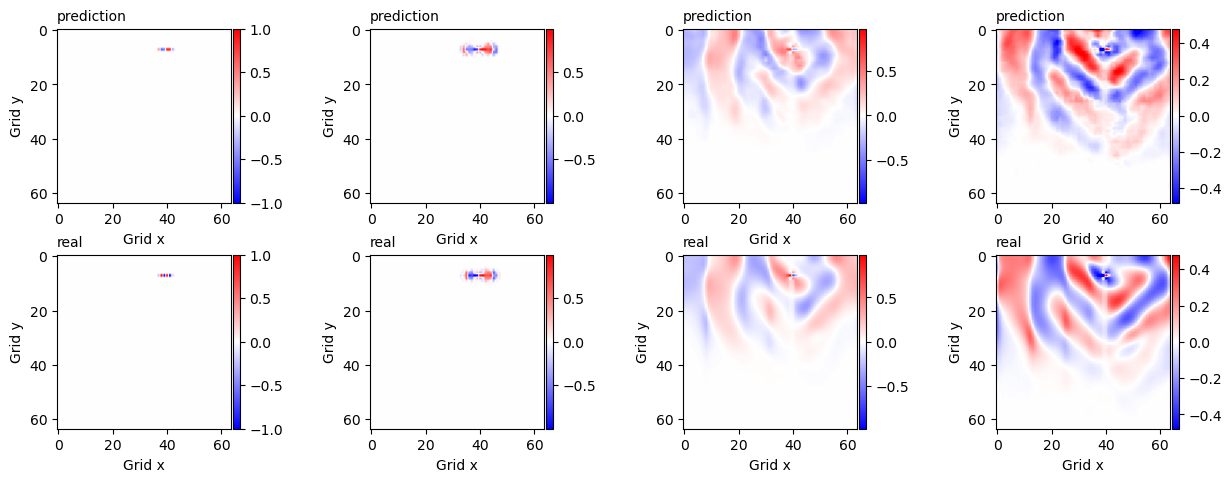

In [54]:
from Plotting_class import add_colorbar
Model_index = int(np.random.randint(Models_test_sub.shape[0], size=1))
with torch.no_grad():
    im_validation = model(torch.unsqueeze(Models_test_sub[Model_index,:,:,:].repeat(1,1,time_prediction_number,1), dim=0).to(device),  
                          torch.unsqueeze((vx_x_test_reshape_sub[Model_index,:,:,:input_time,:].permute(0, 1, 3, 2)).repeat(1, 1, time_prediction_number,1).to(device), dim=0), dx=40, dy=40, dt=0.002)
print("this is the shape of im_validation",im_validation.shape)

plot_time_step_1 = 0
plot_time_step_2 = 10
plot_time_step_3 = 175
plot_time_step_4 = -1


color = 'bwr'
fontsize_plt = 10
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(im_validation[:,:,:,plot_time_step_1].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().min(), 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 0])
im =ax.imshow(vx_x_test_reshape_sub[Model_index,:,:,plot_time_step_1].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().min(), 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_1].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


###############################################################################################

ax = fig.add_subplot(gs[0, 1])
im =ax.imshow(im_validation[:,:,:,plot_time_step_2].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().min(), 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 1])
im =ax.imshow(vx_x_test_reshape_sub[Model_index,:,:,plot_time_step_2].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().min(), 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_2].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


###############################################################################################

ax = fig.add_subplot(gs[0, 2])
im =ax.imshow(im_validation[:,:,:,plot_time_step_3].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().min(), 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().max())
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 2])
im =ax.imshow(vx_x_test_reshape_sub[Model_index,:,:,plot_time_step_3].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().min(), 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_3].squeeze().detach().cpu().max())
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


###############################################################################################

ax = fig.add_subplot(gs[0, 3])
im =ax.imshow(im_validation[:,:,:,plot_time_step_4].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().min()/2, 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().max()/2)
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("prediction", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")


ax = fig.add_subplot(gs[1, 3])
im =ax.imshow(vx_x_test_reshape_sub[Model_index,:,:,plot_time_step_4].squeeze().detach().cpu(), cmap=color, 
             vmin = vx_x_test_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().min()/2, 
              vmax = vx_x_test_reshape_sub[:,:,:,plot_time_step_4].squeeze().detach().cpu().max()/2)
ax.set_ylabel("Grid y", fontsize=fontsize_plt)
ax.set_xlabel("Grid x", fontsize=fontsize_plt)
ax.set_title("real", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

plt.subplots_adjust(left=0.125,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.3)